In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm

from ase.io import read
from mace.calculators import MACECalculator

from tensorpotential.calculator import TPCalculator


from sklearn.metrics import r2_score
import seaborn as sns
from sklearn.metrics import root_mean_squared_error

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
2025-11-04 10:28:28.216296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762248508.228978 1207948 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762248508.234515 1207948 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762248508.251007 1207948 computati

In [2]:
ref_structures = read("../data/b_off_2.0_ood_original.xyz", ":")
structures = read("../data/b_off_2.0_ood_original.xyz", ":")

# ref_structures = read("../data/a_wpS_ood.xyz", ":")
# structures = read("../data/a_wpS_ood.xyz", ":")

In [3]:
def calculate_energies_and_forces(model_type, layer, size, structures, ref_structures):

    pred_energies = []
    ref_energies = []
    pred_forces = []
    ref_forces = []

    if model_type.upper() == "MACE":
        if size == "medium":
            model_paths = f"../models/MACE-OFF24_{size}.model"
        else:
            model_paths = f"../models/MACE-OFF23_{size}.model"
        calc = MACECalculator(
            model_paths=model_paths,
            device="cuda",
        )
    elif model_type.upper() == "GRACE":
        calc = TPCalculator(model=f"../models/{layer}/a_wpS_{size}/seed/1/saved_model/")

    for i, struc in enumerate(tqdm.tqdm(structures)):

        if model_type.upper() == "MACE":
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].info["total_energy"])

        elif model_type.upper() == "GRACE":
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].get_potential_energy())

        pred_forces.append(struc.get_forces())
        ref_forces.append(ref_structures[i].get_forces())

    return (
        pred_energies,
        ref_energies,
        pred_forces,
        ref_forces,
    )

In [4]:
energies = {}

model_types = ["grace"]
layers = ["1l"]
sizes = ["small","medium"]

for model_type in model_types:
    energies[model_type] = {}
    for layer in layers:
        energies[model_type][layer] = {}
        for size in sizes:
            energies[model_type][layer][size] = {}

            (
                energies[model_type][layer][size]["pred_energies"],
                energies[model_type][layer][size]["ref_energies"],
                energies[model_type][layer][size]["pred_forces"],
                energies[model_type][layer][size]["ref_forces"],
            ) = calculate_energies_and_forces(
                model_type,
                layer,
                size,
                structures,
                ref_structures,
            )

I0000 00:00:1762248515.345159 1207948 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43710 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:41:00.0, compute capability: 8.6
  0%|          | 0/10000 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1762248516.310806 1207948 service.cc:152] XLA service 0x559001fb3510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762248516.310872 1207948 service.cc:160]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
2025-11-04 10:28:36.403402: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1762248516.594744 1207948 cuda_dnn.cc:529] Loaded cuDNN version 91301
I0000 00:00:1762248517.924107 1207948 device_compiler.h:188] Compiled cluster using XLA!  This 

In [5]:
for prop in ["energies", "forces"]:
    print(f"##### {prop} results #####")
    for model_type in model_types:
        for layer in layers:
            for size in sizes:

                if prop == "forces":
                    predicted = np.concatenate(
                        energies[model_type][layer][size][f"pred_{prop}"]
                    )
                    reference = np.concatenate(
                        energies[model_type][layer][size][f"ref_{prop}"]
                    )
                else:
                    predicted = np.array(
                        energies[model_type][layer][size][f"pred_{prop}"]
                    )
                    reference = np.array(
                        energies[model_type][layer][size][f"ref_{prop}"]
                    )

                mae = np.mean(np.abs(predicted - reference))
                rmse = root_mean_squared_error(reference, predicted)
                r2 = r2_score(reference, predicted)

                # Store metrics in the dictionary
                energies[model_type][layer][size][f"total_{prop}_mae"] = mae
                energies[model_type][layer][size][f"total_{prop}_rmse"] = rmse
                energies[model_type][layer][size][f"total_{prop}_r2"] = r2

                print(
                    f"Model: {model_type.upper()}, Layer: {layer}, Size: {size}, MAE: {mae*1000:.4f} meV, RMSE: {rmse*1000:.4f} meV, R²: {r2:.4f}"
                )

# Manually add pre-computed MACE total metrics
# The values are divided by 1000 to convert from meV to eV
if "mace" not in energies:
    energies["mace"] = {"N/A": {"small": {}, "medium": {}}}

energies["mace"]["N/A"]["small"]["total_energies_mae"] = 43.0719 / 1000
energies["mace"]["N/A"]["small"]["total_energies_rmse"] = 88.3665 / 1000
energies["mace"]["N/A"]["small"]["total_energies_r2"] = 1.0000
energies["mace"]["N/A"]["small"]["total_forces_mae"] = 31.9850 / 1000
energies["mace"]["N/A"]["small"]["total_forces_rmse"] = 64.0469 / 1000
energies["mace"]["N/A"]["small"]["total_forces_r2"] = 0.9961

energies["mace"]["N/A"]["medium"]["total_energies_mae"] = 26.9742 / 1000
energies["mace"]["N/A"]["medium"]["total_energies_rmse"] = 54.2475 / 1000
energies["mace"]["N/A"]["medium"]["total_energies_r2"] = 1.0000
energies["mace"]["N/A"]["medium"]["total_forces_mae"] = 20.6761 / 1000
energies["mace"]["N/A"]["medium"]["total_forces_rmse"] = 47.7470 / 1000
energies["mace"]["N/A"]["medium"]["total_forces_r2"] = 0.9978

print("\nMACE total metrics loaded into the `energies` dictionary.")


def print_mace_results():
    print(
        """#####################################
#### MACE results for comparison ####
##### energies results ##############
Model: MACE, Size: small, MAE: 43.0719 meV, RMSE: 88.3665 meV, R²: 1.0000
Model: MACE, Size: medium, MAE: 26.9742 meV, RMSE: 54.2475 meV, R²: 1.0000
##### forces results #####
Model: MACE, Size: small, MAE: 31.9850 meV, RMSE: 64.0469 meV, R²: 0.9961
Model: MACE, Size: medium, MAE: 20.6761 meV, RMSE: 47.7470 meV, R²: 0.9978"""
    )


# print_mace_results()

##### energies results #####
Model: GRACE, Layer: 1l, Size: small, MAE: 369.4995 meV, RMSE: 534.4247 meV, R²: 0.9999
Model: GRACE, Layer: 1l, Size: medium, MAE: 343.0527 meV, RMSE: 539.4285 meV, R²: 0.9999
##### forces results #####
Model: GRACE, Layer: 1l, Size: small, MAE: 114.4415 meV, RMSE: 240.9801 meV, R²: 0.9476
Model: GRACE, Layer: 1l, Size: medium, MAE: 86.6541 meV, RMSE: 217.4860 meV, R²: 0.9573

MACE total metrics loaded into the `energies` dictionary.


In [6]:
energies["nr_of_atoms"] = []
for struc in structures:
    energies["nr_of_atoms"].append(len(struc))

In [7]:
for model_type in model_types:
    print(f"##### {model_type.upper()} results #####")
    for layer in layers:
        for size in sizes:

            print(f"--- {layer} layer, {size} size ---")
            pred_E = np.asarray(energies[model_type][layer][size]["pred_energies"])
            ref_E = np.asarray(energies[model_type][layer][size]["ref_energies"])
            natoms = np.asarray(energies["nr_of_atoms"][0 : len(pred_E)])

            # Calculate energy metrics
            energy_rmse_per_atom = np.sqrt(np.mean(((pred_E - ref_E) / natoms) ** 2))
            energy_mae_per_atom = np.mean(np.abs((pred_E - ref_E) / natoms))

            # Store energy metrics
            energies[model_type][layer][size][
                "energy_rmse_per_atom"
            ] = energy_rmse_per_atom
            energies[model_type][layer][size][
                "energy_mae_per_atom"
            ] = energy_mae_per_atom

            print("Energy RMSE per atom (meV):", f"{energy_rmse_per_atom * 1000:.2f}")
            print("Energy MAE per atom (meV):", f"{energy_mae_per_atom * 1000:.2f}")

            pred_list = energies[model_type][layer][size]["pred_forces"]
            ref_list = energies[model_type][layer][size]["ref_forces"]

            # stack diffs over all molecules
            diffs = [np.asarray(p) - np.asarray(r) for p, r in zip(pred_list, ref_list)]
            D = np.concatenate(diffs, axis=0)  # shape (sum_i N_i, 3)

            force_rmse_per_atom = np.sqrt(np.mean(D**2))  # eV/Å
            force_mae_per_atom = np.mean(np.abs(D))  # eV/Å

            # Store force metrics
            energies[model_type][layer][size][
                "force_rmse_per_atom"
            ] = force_rmse_per_atom
            energies[model_type][layer][size]["force_mae_per_atom"] = force_mae_per_atom

            print(f"Forces RMSE per atom (meV/Å): {force_rmse_per_atom*1000:.4f}")
            print(f"Forces MAE per atom (meV/Å):  {force_mae_per_atom*1000:.4f}")

# Manually add pre-computed MACE results
# The values are divided by 1000 to convert from meV to eV, to match the units of the GRACE calculations
energies["mace"] = {
    "N/A": {
        "small": {
            "energy_rmse_per_atom": 2.54 / 1000,
            "energy_mae_per_atom": 1.26 / 1000,
            "force_rmse_per_atom": 64.0469 / 1000,
            "force_mae_per_atom": 31.9850 / 1000,
        },
        "medium": {
            "energy_rmse_per_atom": 1.87 / 1000,
            "energy_mae_per_atom": 0.81 / 1000,
            "force_rmse_per_atom": 47.7470 / 1000,
            "force_mae_per_atom": 20.6761 / 1000,
        },
    }
}
# print(
#     """#######################################
# ##### MACE results for comparison #####
# --- SMALL model ---
# Energy RMSE per atom (meV): 2.54
# Energy MAE per atom (meV): 1.26
# Forces RMSE per atom (meV/Å): 64.0469
# Forces MAE per atom (meV/Å):  31.9850
# --- MEDIUM model ---
# Energy RMSE per atom (meV): 1.87
# Energy MAE per atom (meV): 0.81
# Forces RMSE per atom (meV/Å): 47.7470
# Forces MAE per atom (meV/Å):  20.6761"""
# )

##### GRACE results #####
--- 1l layer, small size ---
Energy RMSE per atom (meV): 24.80
Energy MAE per atom (meV): 13.24
Forces RMSE per atom (meV/Å): 241.2077
Forces MAE per atom (meV/Å):  114.4415
--- 1l layer, medium size ---
Energy RMSE per atom (meV): 22.51
Energy MAE per atom (meV): 11.82
Forces RMSE per atom (meV/Å): 217.7130
Forces MAE per atom (meV/Å):  86.6541


/tmp/ipykernel_1207948/3703611238.py:53: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1207948/3703611238.py:78: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1207948/3703611238.py:103: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1207948/3703611238.py:128: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(


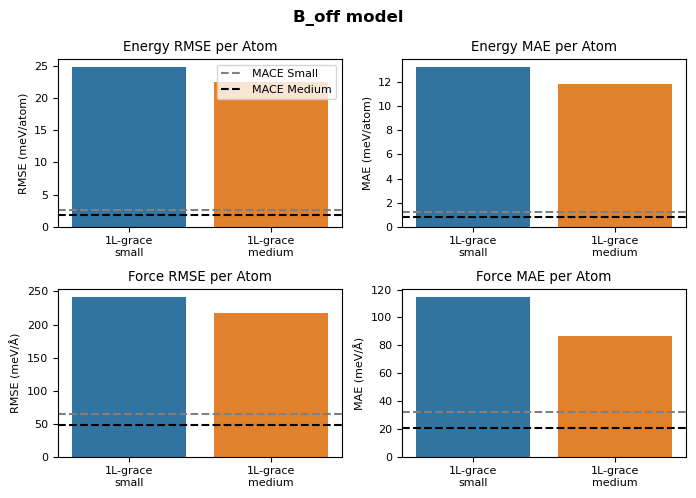

In [19]:
import seaborn as sns

# Prepare data for plotting
model_labels = []
energy_rmse_values = []
energy_mae_values = []
force_rmse_values = []
force_mae_values = []

for model_type in model_types:
    for layer in layers:
        for size in sizes:
            label = f"{layer.upper()}-{model_type}\n{size}"
            model_labels.append(label)

            energy_rmse_values.append(
                energies[model_type][layer][size]["energy_rmse_per_atom"] * 1000
            )
            energy_mae_values.append(
                energies[model_type][layer][size]["energy_mae_per_atom"] * 1000
            )
            force_rmse_values.append(
                energies[model_type][layer][size]["force_rmse_per_atom"] * 1000
            )
            force_mae_values.append(
                energies[model_type][layer][size]["force_mae_per_atom"] * 1000
            )

# Define consistent colors for each model
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Create the plots with Seaborn
fig, axs = plt.subplots(2, 2, figsize=(7, 5))

# --- MACE reference values ---
mace_metrics = {
    "small": {
        "energy_rmse": energies["mace"]["N/A"]["small"]["energy_rmse_per_atom"] * 1000,
        "energy_mae": energies["mace"]["N/A"]["small"]["energy_mae_per_atom"] * 1000,
        "force_rmse": energies["mace"]["N/A"]["small"]["force_rmse_per_atom"] * 1000,
        "force_mae": energies["mace"]["N/A"]["small"]["force_mae_per_atom"] * 1000,
    },
    "medium": {
        "energy_rmse": energies["mace"]["N/A"]["medium"]["energy_rmse_per_atom"] * 1000,
        "energy_mae": energies["mace"]["N/A"]["medium"]["energy_mae_per_atom"] * 1000,
        "force_rmse": energies["mace"]["N/A"]["medium"]["force_rmse_per_atom"] * 1000,
        "force_mae": energies["mace"]["N/A"]["medium"]["force_mae_per_atom"] * 1000,
    },
}


# Energy RMSE per atom
sns.barplot(
    ax=axs[0, 0],
    x=model_labels,
    y=energy_rmse_values,
    hue=model_labels,
    palette=model_colors,
    legend=False,
)
axs[0, 0].axhline(
    y=mace_metrics["small"]["energy_rmse"],
    color="gray",
    linestyle="--",
    label="MACE Small",
)
axs[0, 0].axhline(
    y=mace_metrics["medium"]["energy_rmse"],
    color="black",
    linestyle="--",
    label="MACE Medium",
)
axs[0, 0].set_title("Energy RMSE per Atom")
axs[0, 0].set_ylabel("RMSE (meV/atom)")
axs[0, 0].set_xlabel("")

# Energy MAE per atom
sns.barplot(
    ax=axs[0, 1],
    x=model_labels,
    y=energy_mae_values,
    hue=model_labels,
    palette=model_colors,
    legend=False,
)
axs[0, 1].axhline(
    y=mace_metrics["small"]["energy_mae"],
    color="gray",
    linestyle="--",
    label="MACE Small",
)
axs[0, 1].axhline(
    y=mace_metrics["medium"]["energy_mae"],
    color="black",
    linestyle="--",
    label="MACE Medium",
)
axs[0, 1].set_title("Energy MAE per Atom")
axs[0, 1].set_ylabel("MAE (meV/atom)")
axs[0, 1].set_xlabel("")

# Force RMSE per atom
sns.barplot(
    ax=axs[1, 0],
    x=model_labels,
    y=force_rmse_values,
    hue=model_labels,
    palette=model_colors,
    legend=False,
)
axs[1, 0].axhline(
    y=mace_metrics["small"]["force_rmse"],
    color="gray",
    linestyle="--",
    label="MACE Small",
)
axs[1, 0].axhline(
    y=mace_metrics["medium"]["force_rmse"],
    color="black",
    linestyle="--",
    label="MACE Medium",
)
axs[1, 0].set_title("Force RMSE per Atom")
axs[1, 0].set_ylabel("RMSE (meV/Å)")
axs[1, 0].set_xlabel("")

# Force MAE per atom
sns.barplot(
    ax=axs[1, 1],
    x=model_labels,
    y=force_mae_values,
    hue=model_labels,
    palette=model_colors,
    legend=False,
)
axs[1, 1].axhline(
    y=mace_metrics["small"]["force_mae"],
    color="gray",
    linestyle="--",
    label="MACE Small",
)
axs[1, 1].axhline(
    y=mace_metrics["medium"]["force_mae"],
    color="black",
    linestyle="--",
    label="MACE Medium",
)
axs[1, 1].set_title("Force MAE per Atom")
axs[1, 1].set_ylabel("MAE (meV/Å)")
axs[1, 1].set_xlabel("")
axs[0, 0].legend()

fig.suptitle("B_off model", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("a_wpS_bar.png", dpi=300)
plt.show()
